In [1]:
print("hello")

hello


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [4]:
# 컬럼 분포 확인
def check_category_summary(df, df_name, col_name):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 {col_name} 범주 확인")
    print(f"{'='*80}\n")
    
    summary_df = df[col_name].value_counts(dropna=False).reset_index()
    summary_df.columns = [col_name, '개수']
    summary_df['비율(%)'] = (summary_df['개수'] / len(df) * 100).round(2)
    
    display(summary_df.head(10))

In [5]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("clean_data/starbucks_merge.csv")

# 테이블 복제
# informational은 completed 개념이 없으니 제거하고 시작
# 필요시 그냥 df2 = df.copy() 사용
# df2 = df[df['offer_type'] != 'informational'].copy()
df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,306137
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,10.84,272955,89.16,4
amount,float64,138953,45.39,167184,54.61,5103
offer_id,str,167184,54.61,138953,45.39,10
offer_reward,float64,167184,54.61,138953,45.39,5
difficulty,float64,167184,54.61,138953,45.39,5
duration,float64,167184,54.61,138953,45.39,5
channels,str,167184,54.61,138953,45.39,4
offer_type,str,167184,54.61,138953,45.39,3
web,float64,167184,54.61,138953,45.39,2
mobile,float64,167184,54.61,138953,45.39,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


In [6]:
# ============================================================
# received / viewed / completed 이벤트 분리
# ============================================================
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# viewed 분리
viewed = (
    df2[df2['event'] == 'offer viewed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_viewed'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("viewed 행 수:", len(viewed))
print("completed 행 수:", len(completed))

received 행 수: 76277
viewed 행 수: 57725
completed 행 수: 33182


In [7]:
# ============================================================
# 정렬 + 기준키 생성
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

viewed = viewed.sort_values(
    ["customer_id", "offer_id", "time_viewed"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 기준 고유 행 번호 만들기
received["received_idx"] = received.index

# 오퍼 유효 종료 시점
received["offer_end_time"] = received["time_received"] + received["duration"] * 24

In [9]:
# ============================================================
# 공통 매칭 함수
# - event를 가장 최근의 유효한 base 이벤트에 연결
# - 시간 순서 맞게
# - duration 안의 이벤트만 인정
# - 1대1방식으로 (한 base는 같은 방식에서 1번만 사용)
# - 속도 개선 버전
# ============================================================
def match_event_to_base(
        base_df,           # 기준이 되는 이벤트 테이블(received 또는 viewed)
        event_df,          # base에 연결할 이벤트 테이블(viewed 또는 completed)
        base_time_col,     # base 이벤트의 시간 컬럼명
        event_time_col,    # 연결할 event의 시간 컬럼명
        matched_time_col,  # 매칭 후 result에 새로 붙일 시간 컬럼명
        base_id_col="received_idx"  # base 행을 구분하는 고유 식별 컬럼명
        ):
    """
    received 또는 viewed를 기준으로 잡고 그 뒤에 일어난 viewed/completed를
    같은 고객과 같은 오퍼 안에서 가장 최근의 유효한 base에 1대1로 연결
    """
    
    # 매칭 결과를 저장할 리스트
    match_rows = []

    # base 이벤트(received 또는 viewed?) 고객, 오퍼, 시간 순서대로 정렬
    # -> 불필요한 컬럼을 줄여서 속도와 메모리 사용을 줄임
    base_sorted = (
        base_df[["customer_id", "offer_id", base_id_col, base_time_col, "offer_end_time"]]
        .sort_values(["customer_id", "offer_id", base_time_col])
        .reset_index(drop=True)
    )

    # event 이벤트(viewed 또는 completed) 고객, 오퍼, 시간 순서대로 정렬
    # 이벤트 발생 순서대로 base와 연결
    event_sorted = (
        event_df[["customer_id", "offer_id", event_time_col]]
        .sort_values(["customer_id", "offer_id", event_time_col])
        .reset_index(drop=True)
    )

    # base를 customer_id + offer_id 그룹별로 한 번만 저장
    # -> 반복문 안에서 base_group을 계속 다시 찾지 않기 위함
    # -> numpy 배열로 바꿔서 더 빠르게 처리
    base_groups = {
        key: group[[base_id_col, base_time_col, "offer_end_time"]].to_numpy()
        for key, group in base_sorted.groupby(["customer_id", "offer_id"], sort=False)
    }

    # event를 customer_id + offer_id 단위로 묶어서 반복
    for key, event_group in event_sorted.groupby(["customer_id", "offer_id"], sort=False):

        # 현재 그룹에 해당하는 base 가져오기
        bases = base_groups.get(key)

        # 해당 고객+오퍼의 base가 아예 없으면 다음 그룹으로
        if bases is None:
            continue

        # numpy 배열에서 필요한 값 분리
        # base_ids        : base 행의 고유 식별값
        # base_times      : base 발생 시간
        # offer_end_times : 각 base의 유효 종료 시점
        base_ids = bases[:, 0]
        base_times = bases[:, 1].astype(float)
        offer_end_times = bases[:, 2].astype(float)

        # 같은 방식에서 한 base는 1번만 사용
        # -> 이미 사용한 base는 True로 바뀜
        used = np.zeros(len(bases), dtype=bool)

        # event 발생 시간을 하나씩 확인하면서 조건에 맞는 base 찾기
        for event_time in event_group[event_time_col].to_numpy(dtype=float):

            # event_time 이하인 base 중
            # 가장 최근 base 위치를 빠르게 찾음
            # -> searchsorted는 정렬된 배열에서 위치를 빠르게 찾는 함수
            j = np.searchsorted(base_times, event_time, side="right") - 1

            # 가장 최근 후보부터 뒤에서 앞으로 확인
            # -> event와 가장 가까운 이전 base를 선택하기 위함
            while j >= 0:

                # 조건 1 아직 사용되지 않은 base인가?
                # 조건 2 event가 offer_end_time 이내인가?
                # -> duration 안에서 일어난 이벤트만 인정
                if (not used[j]) and (offer_end_times[j] >= event_time):
                    match_rows.append({
                        base_id_col: base_ids[j],
                        matched_time_col: event_time
                    })

                    # 사용한 base는 다시 못 쓰게 저장
                    used[j] = True
                    break

                # 조건이 안 맞으면 더 이전 base를 확인
                j -= 1

    # 최종 결과는 base_df를 기준으로 유지
    result = base_df.copy()

    # 매칭 결과가 하나도 없으면 결측치로 만든 뒤 반환
    if not match_rows:
        result[matched_time_col] = pd.NA
        return result

    # 매칭 결과 리스트를 DataFrame으로 변환
    match_df = pd.DataFrame(match_rows)

    # base_df와 매칭 결과를 base_id_col 기준으로 왼쪽 병합
    # -> 매칭 성공한 행은 시간값이 붙고
    # -> 실패한 행은 NaN으로 남음
    result = result.merge(
        match_df,
        on=base_id_col,
        how="left"
    )

    return result

In [10]:
# ============================================================
# 1) received -> viewed 매칭
# ============================================================
rv = match_event_to_base(
    base_df=received,                 # 기준: 받은 오퍼(received)
    event_df=viewed,                  # 연결 대상: 열람 이벤트(viewed)
    base_time_col="time_received",    # 기준 시간: 오퍼 받은 시점
    event_time_col="time_viewed",     # 연결할 이벤트 시간: 오퍼 본 시점
    matched_time_col="time_viewed"    # 결과로 붙일 컬럼명
)

In [11]:
# ============================================================
# 2) received -> completed 매칭
# ============================================================
rc_match = match_event_to_base(
    base_df=received,                    # 기준: 받은 오퍼(received)
    event_df=completed,                  # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_received",       # 기준 시간: 오퍼 받은 시점
    event_time_col="time_completed",     # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_rc" # 결과로 붙일 컬럼명(received→completed용)
)


In [12]:
# ============================================================
# 3) viewed -> completed 매칭
# viewed가 붙은 received만 대상으로, viewed 이후 completed를 다시 매칭
# ============================================================
view_base = rv[rv["time_viewed"].notna()].copy()

vc_match = match_event_to_base(
    base_df=view_base,                  # 기준: viewed가 확인된 received
    event_df=completed,                 # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_viewed",        # 기준 시간: 오퍼 본 시점
    event_time_col="time_completed",    # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_vc" # 결과로 붙일 컬럼명(viewed→completed용)
)

In [13]:
# ============================================================
# 최종 received 기준 퍼널 테이블 생성
# ============================================================
funnel = received.copy()

# received -> viewed 매칭 결과 붙이기
funnel = funnel.merge(
    rv[["received_idx", "time_viewed"]],
    on="received_idx",
    how="left"
)

# received -> completed 매칭 결과 붙이기
funnel = funnel.merge(
    rc_match[["received_idx", "time_completed_rc"]],
    on="received_idx",
    how="left"
)

# 시간 차이 계산
# 각 단계까지 걸린 시간을 계산
funnel = funnel.merge(
    vc_match[["received_idx", "time_completed_vc"]],
    on="received_idx",
    how="left"
)

# 시간 차이
funnel["rv_time_diff"] = funnel["time_viewed"] - funnel["time_received"]
funnel["rc_time_diff"] = funnel["time_completed_rc"] - funnel["time_received"]
funnel["vc_time_diff"] = funnel["time_completed_vc"] - funnel["time_viewed"]

# 유효 여부 플래그
# 시간값이 존재하면 1, 없으면 0으로 변환
funnel["has_viewed"] = funnel["time_viewed"].notna().astype(int)
funnel["has_completed_rc"] = funnel["time_completed_rc"].notna().astype(int)
funnel["has_completed_after_view"] = funnel["time_completed_vc"].notna().astype(int)

# 전환 플래그
# converted_rv  : received -> viewed 전환 여부
funnel["converted_rv"] = funnel["has_viewed"]

# converted_rc  : received -> completed 전환 여부
funnel["converted_rc"] = funnel["has_completed_rc"]

# converted_vc  : viewed -> completed 전환 여부
funnel["converted_vc"] = funnel["has_completed_after_view"]

# converted_rvc : received -> viewed -> completed 전환 여부
funnel["converted_rvc"] = (
    (funnel["has_viewed"] == 1) &
    (funnel["has_completed_after_view"] == 1)
).astype(int)

# 기존 코드 호환용
# 기존 converted_final 의미를 유지하려면 received -> completed로 둠
funnel["converted_final"] = funnel["converted_rc"]

In [ ]:
# ------------------------------------------------------------
# 퍼널 분석에 필요한 핵심 컬럼만 선택해서 최종 테이블 형태로 정리
# ------------------------------------------------------------
funnel = funnel[
    [
        'customer_id', 'offer_id',                          # 고객 / 오퍼 식별 정보
        'offer_type', 'offer_reward', 'difficulty', 'duration',   # 오퍼 속성 정보
        'web', 'email', 'mobile', 'social',                # 오퍼 발송 채널 정보

        'time_received', 'offer_end_time',                 # 오퍼 수신 시점 / 오퍼 유효 종료 시점
        'time_viewed', 'time_completed_rc', 'time_completed_vc',   # 단계별 매칭 시간 정보

        'rv_time_diff', 'rc_time_diff', 'vc_time_diff',    # 단계별 소요 시간 정보

        'has_viewed', 'has_completed_rc', 'has_completed_after_view',  # 이벤트 연결 여부 플래그

        'converted_rv', 'converted_rc', 'converted_vc', 'converted_rvc', # 전환 여부 플래그
        'converted_final'                                  # 기존 코드 호환용 최종 전환 컬럼
    ]
].copy()

# ------------------------------------------------------------
# 최종 funnel 테이블의 기본 정보(행/열 수, 결측치, 타입 등) 확인
# ------------------------------------------------------------
check_basic_info(funnel, 'received 기준 funnel 테이블')


received 기준 funnel 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,26
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed_vc,float64,23496,30.80,52781,69.20,120
vc_time_diff,float64,23496,30.80,52781,69.20,41
time_completed_rc,float64,33152,43.46,43125,56.54,120
rc_time_diff,float64,33152,43.46,43125,56.54,41
time_viewed,float64,56567,74.16,19710,25.84,120
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,time_viewed,time_completed_rc,time_completed_vc,rv_time_diff,rc_time_diff,vc_time_diff,has_viewed,has_completed_rc,has_completed_after_view,converted_rv,converted_rc,converted_vc,converted_rvc,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,576.0,NaN,NaN,0.0,NaN,0,1,0,0,1,0,0,1
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,372.0,NaN,NaN,36.0,NaN,NaN,1,0,0,1,0,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,192.0,NaN,NaN,24.0,NaN,NaN,1,0,0,1,0,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,456.0,414.0,NaN,48.0,6.0,NaN,1,1,0,1,1,0,0,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,540.0,528.0,NaN,36.0,24.0,NaN,1,1,0,1,1,0,0,1


In [30]:
funnel_offer = funnel[funnel['offer_type'] != 'informational'].copy()

def make_status_summary(df, group_col):
    temp = df.copy()

    temp['status'] = np.select(
        [
            temp['converted_rc'] == 1,
            temp['has_viewed'] == 0,
            (temp['has_viewed'] == 1) & (temp['converted_rc'] == 0)
        ],
        [
            'converted',
            'not_viewed',
            'viewed_not_converted'
        ],
        default='other'
    )

    summary = (
        temp.groupby([group_col, 'status'])
        .size()
        .unstack(fill_value=0)
    )

    ratio = summary.div(summary.sum(axis=1), axis=0)
    return ratio

In [31]:
def plot_status_stacked_bar(ratio, group_col, title):
    ax = ratio[['converted', 'not_viewed', 'viewed_not_converted']].plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('비율')
    ax.legend(title='status', bbox_to_anchor=(1.02, 1), loc='upper left')

    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            labels.append(f'{h:.1%}' if h > 0.03 else '')
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white')

    plt.tight_layout()
    plt.show()

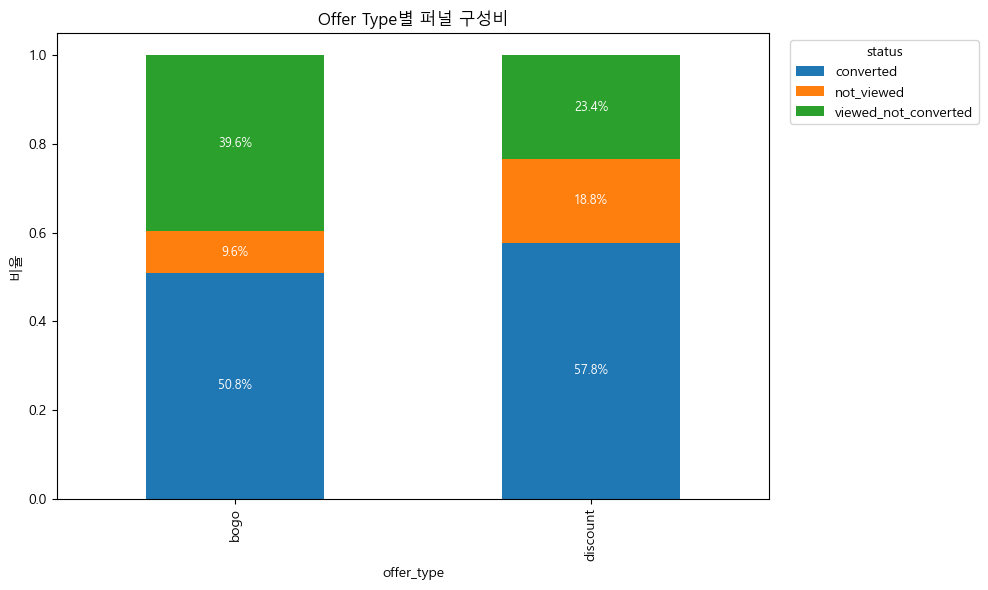

In [32]:
offer_type_ratio = make_status_summary(funnel_offer, 'offer_type')
plot_status_stacked_bar(
    offer_type_ratio,
    group_col='offer_type',
    title='Offer Type별 퍼널 구성비'
)

[핵심 결과]
- discount
전환율: 57.8% (높음)
viewed_not_converted 낮음 (23.4%)

- bogo
viewed_not_converted: 39.6% (높음)
많이는 보는데 완료 안 함

**단기 매출 증가 목표 => discount 중심 운영**
**bogo 개선 방향 => 조건 완화 or UX 개선 필요**

In [33]:
def make_funnel_summary(df, group_col):
    summary = df.groupby(group_col).agg(
        received=('customer_id', 'count'),
        viewed=('has_viewed', 'sum'),
        completed=('has_completed_rc', 'sum'),
        completed_after_view=('has_completed_after_view', 'sum')
    ).reset_index()

    summary['rv_rate'] = summary['viewed'] / summary['received']
    summary['vc_rate'] = np.where(
        summary['viewed'] > 0,
        summary['completed_after_view'] / summary['viewed'],
        np.nan
    )
    summary['rc_rate'] = summary['completed'] / summary['received']

    return summary.sort_values(group_col)

In [34]:
def plot_funnel_conversion(summary, group_col, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(summary))

    ax.plot(x, summary['rv_rate'], marker='o', label='received → viewed')
    ax.plot(x, summary['vc_rate'], marker='o', label='viewed → completed')
    ax.plot(x, summary['rc_rate'], marker='o', label='received → completed')

    for col in ['rv_rate', 'vc_rate', 'rc_rate']:
        for i, y in enumerate(summary[col]):
            if pd.notna(y):
                ax.text(i, y + 0.02, f'{y:.1%}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(summary[group_col])
    ax.set_ylim(0, 1.05)

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('전환율')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

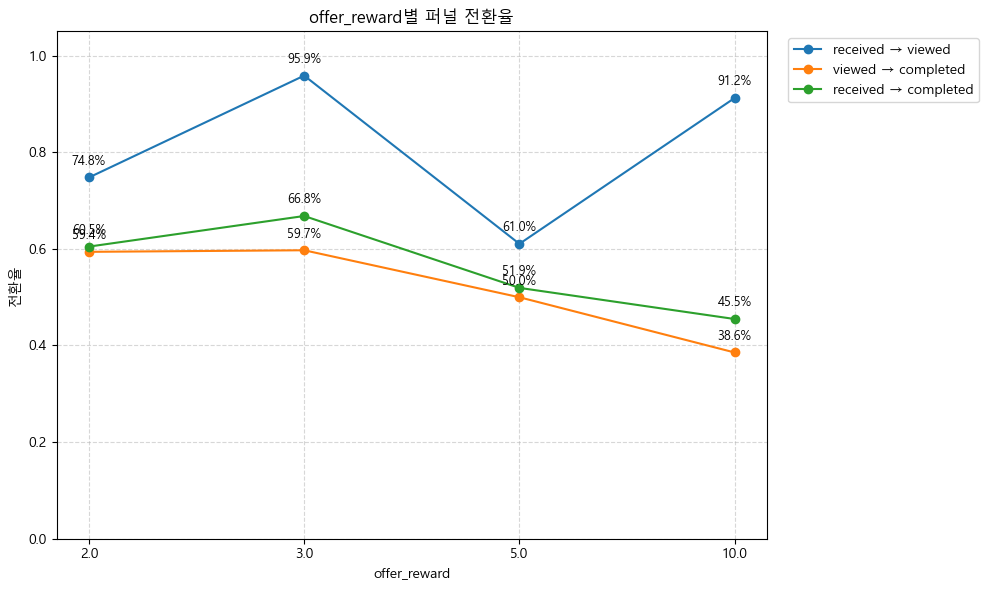

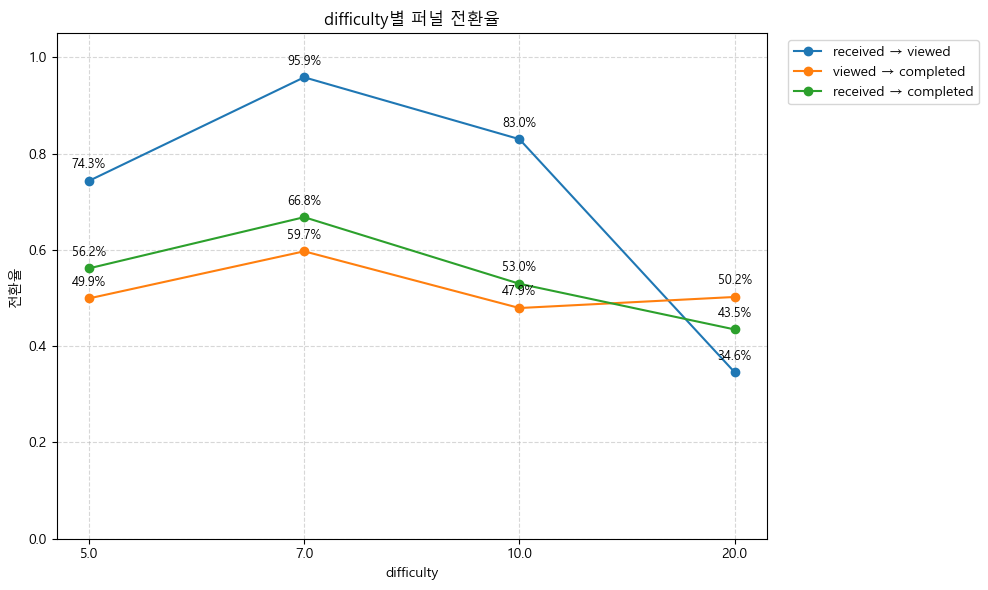

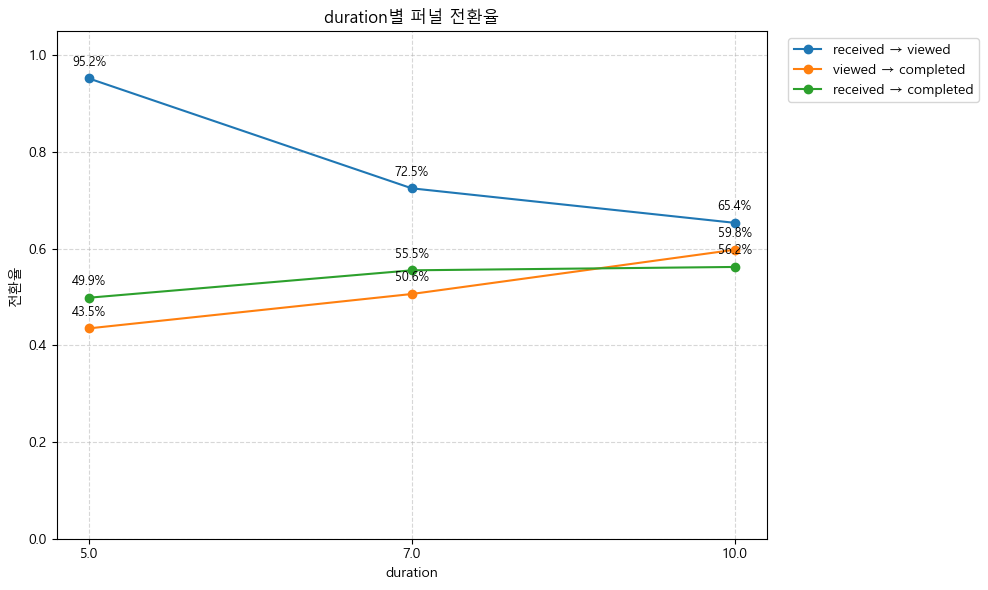

In [35]:
for col in ['offer_reward', 'difficulty', 'duration']:
    summary = make_funnel_summary(funnel_offer, col)
    plot_funnel_conversion(
        summary,
        group_col=col,
        title=f'{col}별 퍼널 전환율'
    )

[간단한 통계]
상관계수: 영향 방향과 크기
p-value: 그 차이가 우연인지 아닌지


상관계수 크지 않음 => 효과 크기는 아주 강하지 않을 수 있음
p-value 매우 작음 => 하지만 그 차이는 우연이 아님을 검증

In [36]:
corr_df = funnel_offer[
    ['offer_reward', 'difficulty', 'duration', 'converted_rc']
].copy()

corr = corr_df.corr()

print("="*60)
print("상관계수 (Correlation)")
print("="*60)
display(corr)

상관계수 (Correlation)


,offer_reward,difficulty,duration,converted_rc
offer_reward,1.000000,0.063459,-0.455509,-0.126113
difficulty,0.063459,1.000000,0.643020,-0.093056
duration,-0.455509,0.643020,1.000000,0.041103
converted_rc,-0.126113,-0.093056,0.041103,1.000000


    변수	  converted_rc와 상관
offer_reward	-0.126
difficulty	    -0.093
duration	    +0.041

In [37]:
from scipy.stats import ttest_ind

print("="*60)
print("p-value (전환 여부에 따른 차이 검정)")
print("="*60)

for col in ['offer_reward', 'difficulty', 'duration']:
    
    group1 = funnel_offer[funnel_offer['converted_rc'] == 1][col]
    group0 = funnel_offer[funnel_offer['converted_rc'] == 0][col]
    
    stat, p = ttest_ind(group1, group0, equal_var=False)
    
    print(f"\n[{col}]")
    print(f"t-statistic: {stat:.4f}")
    print(f"p-value: {p:.6f}")

p-value (전환 여부에 따른 차이 검정)

[offer_reward]
t-statistic: -31.2580
p-value: 0.000000

[difficulty]
t-statistic: -22.8414
p-value: 0.000000

[duration]
t-statistic: 10.1534
p-value: 0.000000


In [38]:
# offer_type 카이제곱 검정
from scipy.stats import chi2_contingency

ct = pd.crosstab(funnel_offer['offer_type'], funnel_offer['converted_rc'])

chi2, p, dof, expected = chi2_contingency(ct)

print("="*60)
print("Offer Type vs Conversion (카이제곱 검정)")
print("="*60)
print("p-value:", p)

Offer Type vs Conversion (카이제곱 검정)
p-value: 8.344696965068119e-67


1. reward 전략
무조건 크게 X
적정 수준 (≈3) 유지

2. difficulty 전략
가장 중요한 변수
낮추는 것이 전환 상승 핵심

3. duration 전략
너무 짧으면 X
7~10일 유지

4. offer_type 전략
discount 중심 운영
bogo는 개선 필요

퍼널 분석을 통해 오퍼의 전환 구조를 분석한 결과,
보상 크기보다 조건 난이도가 전환율에 더 큰 영향을 미치는 것을 확인
또한 t-test와 카이제곱 검정을 통해 reward, difficulty, duration, offer_type 모두
전환율에 통계적으로 유의미한 영향을 미친다는 점을 검증
이를 바탕으로 적정 보상 수준과 낮은 난이도, 충분한 유효기간을 가진 오퍼가
가장 높은 전환 성과를 만든다는 결론 도출

In [39]:
for col in ['offer_reward', 'difficulty', 'duration']:
    group1 = funnel_offer[funnel_offer['converted_rc'] == 1][col]
    group0 = funnel_offer[funnel_offer['converted_rc'] == 0][col]

    stat, p = ttest_ind(group1, group0, equal_var=False)

    print(f"\n[{col}]")
    print(f"t-statistic: {stat:.4f}")
    print(f"p-value: {p:.3e}")


[offer_reward]
t-statistic: -31.2580
p-value: 1.025e-212

[difficulty]
t-statistic: -22.8414
p-value: 5.970e-115

[duration]
t-statistic: 10.1534
p-value: 3.352e-24
